# Pandas Practice 3 (Bike Share Data)

As a data scientist, you don't always have to invent the wheel from scratch. The great advantage of Python is that smart people before you spend a lot of energy on making life easier for the next programers. So please, make your life easier and use code that has already been implemented, don't call it "copying" but "friendly borrowing" of other people's code. If you copy whole functions or great graphs in the future, don't forget to give props to the inventor!

So for this exercise, too, if you get stuck at any point, look at good solutions from others and learn a lot from them about how to solve these problems even better.
Here are two good resources for small code snippet which can be very helpful when dealing with DataFrames:

- [Sebastian Raschkas "Things in Pandas I Wish I'd Known Earlier"](https://nbviewer.jupyter.org/github/rasbt/python_reference/blob/master/tutorials/things_in_pandas.ipynb)
- [Helpful Python Code Snippets for Data Exploration in Pandas](https://medium.com/@msalmon00/helpful-python-code-snippets-for-data-exploration-in-pandas-b7c5aed5ecb9)
- [Manipulating tabular data with Pandas](https://neuroimaging-data-science.org/content/004-scipy/002-pandas.html)


**By the end of this session you should be able to**
- Explore data with Pandas to answer conceptual questions
- Write chained commands for efficient one-liners



In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('data/bike_share_201402_trip_data.csv')

How many observations are there?

In [ ]:
df.shape

# 144015 observations

(144015, 11)

In [11]:
df.head()

,Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscription Type,Zip Code
0,4576,63,8/29/2013 14:13,South Van Ness at Market,66,8/29/2013 14:14,South Van Ness at Market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,San Jose City Hall,10,8/29/2013 14:43,San Jose City Hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,Mountain View City Hall,27,8/29/2013 10:17,Mountain View City Hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,San Jose City Hall,10,8/29/2013 11:30,San Jose City Hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,South Van Ness at Market,66,8/29/2013 12:04,Market at 10th,67,319,Subscriber,94103


Change the columns to be pythonic:

- lowercase 
- replace " " with `_` as a separator
- replace "#" with `num` 


In [13]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("#", "num")

df.columns





Index(['trip_id', 'duration', 'start_date', 'start_station', 'start_terminal',
       'end_date', 'end_station', 'end_terminal', 'bike_num',
       'subscription_type', 'zip_code'],
      dtype='object')

How many types of subscription options are there? What are the different subscription types?

In [15]:
df.subscription_type.unique()

array(['Subscriber', 'Customer'], dtype=object)

In [ ]:
df.subscription_type.nunique()

# there are 2 subscriptions types: "Subdcriber" and "Customer"

2

What is the frequency of each subscription option?

In [37]:
df.groupby("subscription_type").count()["trip_id"]

# Customer       30368
# Subscriber    113647

subscription_type
Customer       30368
Subscriber    113647
Name: trip_id, dtype: int64

In [ ]:
#better: 
df["subscription_type"].value_counts()

subscription_type
Subscriber    113647
Customer       30368
Name: count, dtype: int64

np.int64(144015)

Please plot the frequency of each subscription option with a pie chart:

<Axes: ylabel='count'>

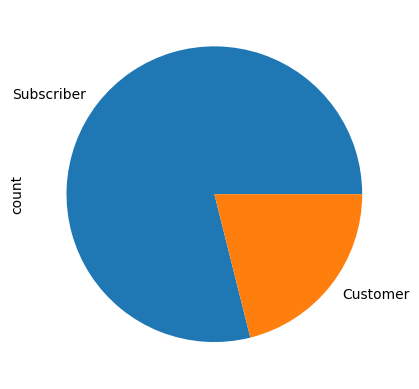

In [33]:
df["subscription_type"].value_counts().plot(kind="pie")

Please plot the frequency of each subscription option with a bar chart:

<Axes: xlabel='subscription_type'>

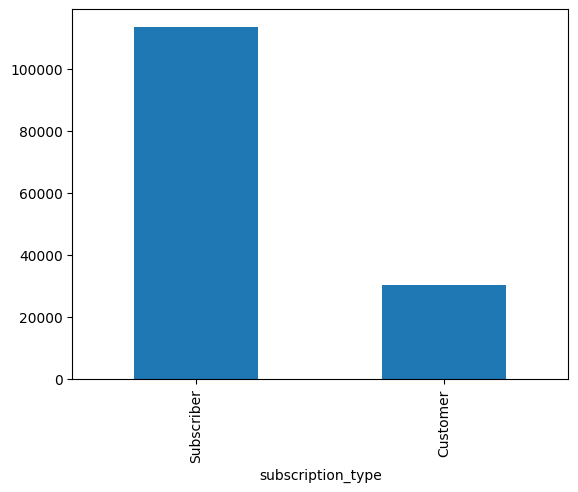

In [39]:
df["subscription_type"].value_counts().plot(kind="bar")

Have a look at the start_station column: Which 10 stations occur most frequently?

In [41]:
df["start_station"].value_counts().head(10)

start_station
San Francisco Caltrain (Townsend at 4th)         9838
Harry Bridges Plaza (Ferry Building)             7343
Embarcadero at Sansome                           6545
Market at Sansome                                5922
Temporary Transbay Terminal (Howard at Beale)    5113
Market at 4th                                    5030
2nd at Townsend                                  4987
San Francisco Caltrain 2 (330 Townsend)          4976
Steuart at Market                                4913
Townsend at 7th                                  4493
Name: count, dtype: int64

Now look at the end_station column: Which 10 stations occur the least often?

In [42]:
df["start_station"].value_counts().tail(10)

start_station
Park at Olive                       189
Castro Street and El Camino Real    132
Redwood City Medical Center         123
San Antonio Shopping Center         108
San Mateo County Center             101
Franklin at Maple                    99
Broadway at Main                     45
Redwood City Public Library          44
San Jose Government Center           23
Mezes Park                            3
Name: count, dtype: int64

In [44]:
df["end_station"].value_counts(ascending=True).head(10)

end_station
Mezes Park                            5
San Jose Government Center           23
Broadway at Main                     56
Franklin at Maple                    93
San Antonio Shopping Center          93
San Mateo County Center             106
Redwood City Public Library         117
Castro Street and El Camino Real    129
Redwood City Medical Center         178
Broadway St at Battery St           205
Name: count, dtype: int64

Create a table that has start_station segmented by subscription_type and include also the row/column margins (subtotals). If you are not sure how to do it, check out the documentation for `pd.crosstab()`.

In [49]:

pd.crosstab(df["start_station"], df["subscription_type"], margins=True)


subscription_type,Customer,Subscriber,All
start_station,,,
2nd at Folsom,427,3349,3776
2nd at South Park,535,3923,4458
2nd at Townsend,882,4105,4987
5th at Howard,606,2029,2635
Adobe on Almaden,75,260,335
...,...,...,...
Townsend at 7th,518,3975,4493
University and Emerson,328,106,434
Washington at Kearney,561,911,1472


Let's look at the duration... Which unit do you think is used here?

How long is the shortest trip? How many are that short?

In [57]:
df["duration"]

shortest = df["duration"].min()
how_many = (df["duration"] == shortest).sum()
print ("the shortest trip is: ", shortest, "and this happend ", how_many, " times")

# unit is probably a second
# the shortest trip is 63 seconds
# only one trip is that short


the shortest trip is:  60 and this happend  17  times


What do you think is going on with the short trips?

In [ ]:
#people accidently used the app or took the bikes and directly changed their mind

What is the longest trip?

In [58]:
longest = df["duration"].max()
longest

np.int64(722236)

In [60]:
in_minutes = longest / 60
in_minutes

in_hours = in_minutes / 60
in_hours

np.float64(200.6211111111111)

How would you define a "long" trip? How many trips are "long" according to your definition?

In [63]:
# a long trip is over 4 hours which are 14400 seconds
print (4*60*60)

(df["duration"] >= 14400).sum()


14400


np.int64(1593)

Do the long durations seem reasonable? Why are they so long? What could it tell us about the users?

In [ ]:
# in some cases people must have forgotten to lock the bikes or couldnt do it because of another reason

Plot the duration column.

<Axes: >

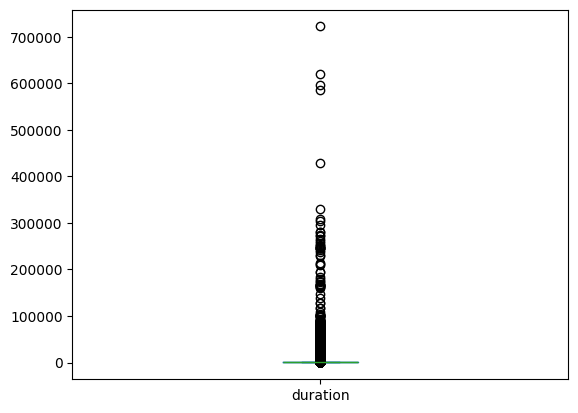

In [68]:
df["duration"].plot(kind="box")

In [ ]:
#df["duration"].plot(kind="hist", bins=100)

df["duration"].plot(kind="scatter")

0            63
1            70
2            71
3            77
4            83
          ...  
144010      385
144011      145
144012      677
144013    64128
144014      570
Name: duration, Length: 144015, dtype: int64

In [73]:
#df[df["duration"] < 20000]["duration"].plot(kind="kde")
#df[df["duration"] < 20000].shape
df[df["duration"] < 20000]["duration"].describe()



count    143079.000000
mean        892.545188
std        1708.381934
min          60.000000
25%         348.000000
50%         528.000000
75%         789.000000
max       19998.000000
Name: duration, dtype: float64

<Axes: ylabel='Frequency'>

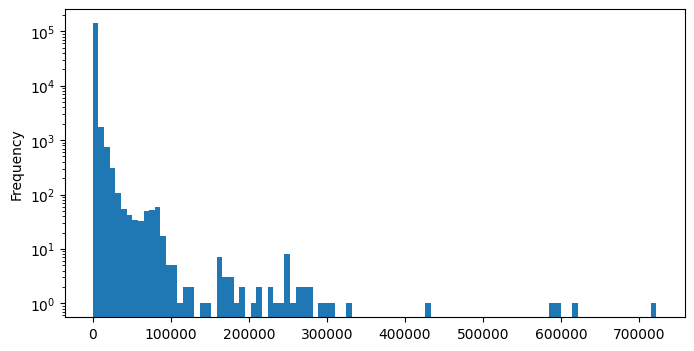

In [79]:
df["duration"].plot(
    kind="hist",
    bins=100,
    log=True,
    figsize=(8,4)
)

Does this plot give any insights?

In [ ]:
#most trips are short, there arw a few very long trips that affect the skewesness but most trips are short

Select subsections of the data to make plots that provide more insights.

In [ ]:
short_trips = df.query("duration < 300").duration
short_trips

long_trips = df.query("duration > 10000").duration
long_trips

0          63
1          70
2          71
3          77
4          83
         ... 
143998    293
144000    277
144004    168
144008    225
144011    145
Name: duration, Length: 25921, dtype: int64

<Axes: ylabel='Frequency'>

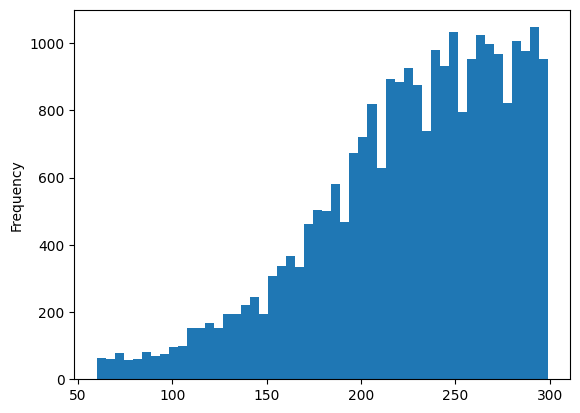

In [95]:
short_trips.plot(kind="hist", bins=50)

<Axes: ylabel='Frequency'>

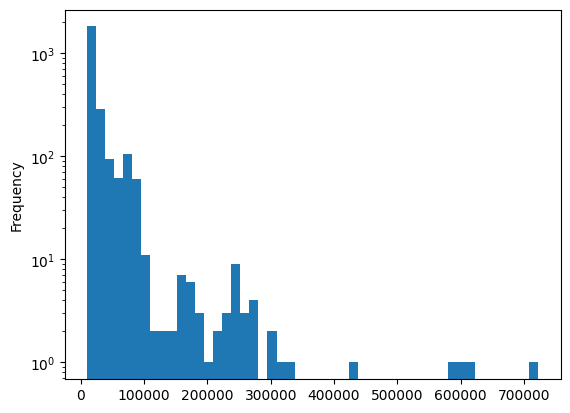

In [93]:
long_trips.plot(kind="hist", bins=50, log=True)

<Axes: ylabel='Frequency'>

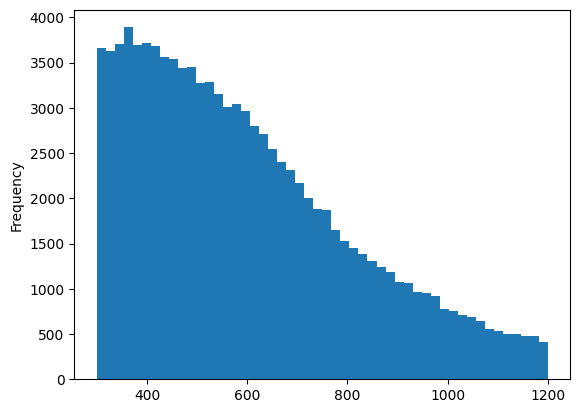

In [96]:
medium = df.query("duration >= 300 and duration <= 1200").duration
medium.plot(kind="hist", bins=50)

The Product Team would like all of the station names to be lower case and  with `_` as a separator

`South Van Ness at Market` -> `south_van_ness_at_market`  

**DO NOT USE A FOR LOOP. THEY ARE THE 👿**

In [111]:
df["start_station"] = df["start_station"].str.lower().str.replace(" ", "_")
#df["start_station"]
df["end_station"] = df["end_station"].str.lower().str.replace(" ", "_")
df[["start_station","end_station"]]

#df.columns = df.columns.str.lower()
#df.columns = df.columns.str.replace(" ", "_")

,start_station,end_station
0,south_van_ness_at_market,south_van_ness_at_market
1,san_jose_city_hall,san_jose_city_hall
2,mountain_view_city_hall,mountain_view_city_hall
3,san_jose_city_hall,san_jose_city_hall
4,south_van_ness_at_market,market_at_10th
...,...,...
144010,powell_street_bart,south_van_ness_at_market
144011,commercial_at_montgomery,davis_at_jackson
144012,embarcadero_at_sansome,market_at_4th
144013,civic_center_bart_(7th_at_market),harry_bridges_plaza_(ferry_building)


Now take a timer and set it to 15 minutes. Take this time to explore the data guided by your own intuition or hypotheses…
> Time boxing is a helpful approach when working with a new dataset so you won't fall into any rabbit holes. 